# Imports

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))
from MC2PCA import MC2PCA
from metrics import ClusteringMetrics
from dataset_manager import DatasetManager

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    confusion_matrix,
)
from scipy.optimize import linear_sum_assignment



# Loading data

In [2]:
ds = DatasetManager("japanese_vowels")
X_train, y_train = ds.X, ds.y

# Training of the model 

In [3]:
y_true_int = np.array(y_train).astype(int)

metrics = ClusteringMetrics()

for p in [1,2,3,4,5]:
    model = MC2PCA(p=p, tol=1e-7, max_iter=100)
    model.fit(X_train, K=9)

    metrics.add_run(
        y_true=y_true_int,
        y_pred=model.assignments,
        p=p,
        X=X_train
    )

# Evaluation

p=1 | ARI=0.269 | NMI=0.412 | Purity=0.537 | Precision=0.537 | Recall=0.498
p=2 | ARI=0.195 | NMI=0.325 | Purity=0.431 | Precision=0.431 | Recall=0.417
p=3 | ARI=0.318 | NMI=0.438 | Purity=0.564 | Precision=0.564 | Recall=0.559
p=4 | ARI=0.287 | NMI=0.412 | Purity=0.519 | Precision=0.519 | Recall=0.511
p=5 | ARI=0.391 | NMI=0.484 | Purity=0.627 | Precision=0.627 | Recall=0.616


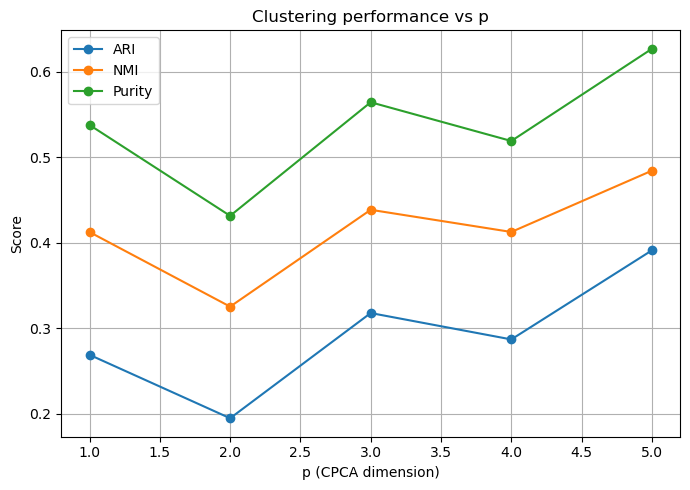

/Users/ilan/anaconda3/envs/kaggle/lib/python3.9/site-packages/matplotlib/axes/_axes.py:1185: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/Users/ilan/anaconda3/envs/kaggle/lib/python3.9/site-packages/matplotlib/axes/_axes.py:1186: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])


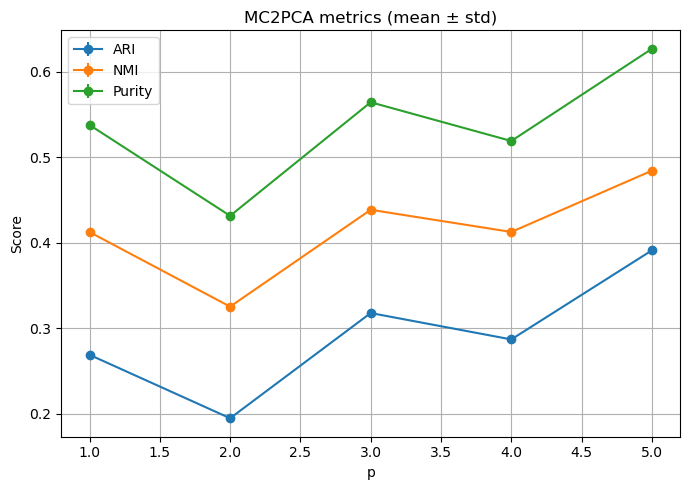

In [4]:
metrics.summary()
metrics.plot_metrics_vs_p()
metrics.plot_metrics_mean_std()

# Evaluate number of components (pca) vs. precision


In [5]:
le = LabelEncoder()
y_true = le.fit_transform(y_train)

ps = [1, 2, 3, 4, 5, 6, 8, 10]
n_runs = 10
K=9

mean_acc = []
std_acc = []

for p in ps:
    for run in range(n_runs):
        perm = np.random.permutation(len(X_train))
        X_perm = [X_train[i] for i in perm]
        y_perm = y_true[perm]

        model = MC2PCA(p=p, tol=1e-7, max_iter=50)
        model.fit(X_perm, K=K)

        y_pred = model.assignments

        metrics.add_run(
            y_true=y_perm,
            y_pred=y_pred,
            p=p,
            errors=model.errors
        )

    subset = [r for r in metrics.results if r["p"] == p]
    precs = [r["Precision"] for r in subset]

    print(
        f"p={p} | Precision = {np.mean(precs):.3f} ± {np.std(precs):.3f}"
    )


p=1 | Precision = 0.504 ± 0.028
p=2 | Precision = 0.517 ± 0.040
p=3 | Precision = 0.526 ± 0.038
p=4 | Precision = 0.532 ± 0.034
p=5 | Precision = 0.524 ± 0.049
p=6 | Precision = 0.488 ± 0.045
p=8 | Precision = 0.419 ± 0.045
p=10 | Precision = 0.308 ± 0.020


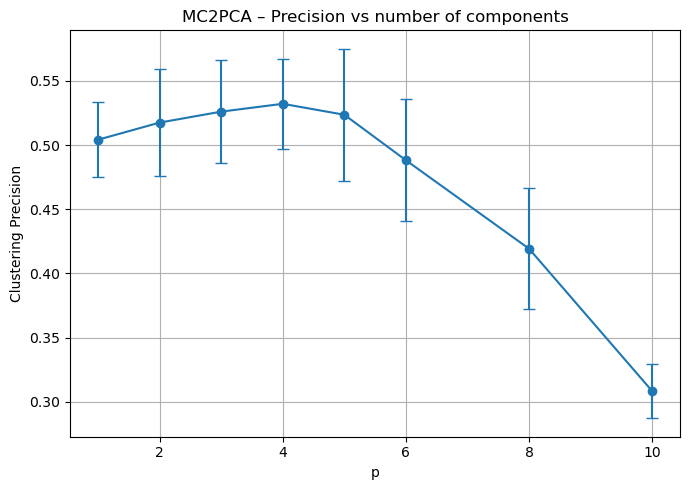

In [6]:
df = pd.DataFrame(metrics.results)
grouped = df.groupby("p")["Precision"].agg(["mean", "std"])

plt.figure(figsize=(7,5))
plt.errorbar(
    grouped.index,
    grouped["mean"],
    yerr=grouped["std"],
    marker="o",
    capsize=4
)

plt.xlabel("p")
plt.ylabel("Clustering Precision")
plt.title("MC2PCA – Precision vs number of components")
plt.grid(True)
plt.tight_layout()
plt.show()


# Evaluate precision vs. adding noise


In [11]:
import numpy as np

def add_gaussian_noise(X, alpha, seed=None):
    rng = np.random.default_rng(seed)
    X_noisy = []

    for Xi in X:
        sigma = Xi.std()
        noise = alpha * sigma * rng.standard_normal(Xi.shape)
        X_noisy.append(Xi + noise)

    return X_noisy

noise_levels = [0.0, 0.05, 0.1, 0.2, 0.3, 0.5]
n_runs = 10

K = 9
p = 3

metrics = ClusteringMetrics()

for alpha in noise_levels:
    for run in range(n_runs):

        perm = np.random.permutation(len(X_train))
        X_perm = [X_train[i] for i in perm]
        y_perm = y_true[perm]

        X_noisy = add_gaussian_noise(X_perm, alpha=alpha, seed=run)

        model = MC2PCA(p=p, tol=1e-7, max_iter=50)
        model.fit(X_noisy, K=K)

        metrics.add_run(
            y_true=y_perm,
            y_pred=model.assignments,
            noise=alpha,             
            errors=model.errors
        )

    subset = [r for r in metrics.results if r["noise"] == alpha]
    precs = [r["Precision"] for r in subset]

    print(
        f"noise={alpha:.2f} | Precision = "
        f"{np.mean(precs):.3f} ± {np.std(precs):.3f}"
    )



noise=0.00 | Precision = 0.547 ± 0.043
noise=0.05 | Precision = 0.539 ± 0.036
noise=0.10 | Precision = 0.523 ± 0.030
noise=0.20 | Precision = 0.443 ± 0.036
noise=0.30 | Precision = 0.423 ± 0.013
noise=0.50 | Precision = 0.306 ± 0.021


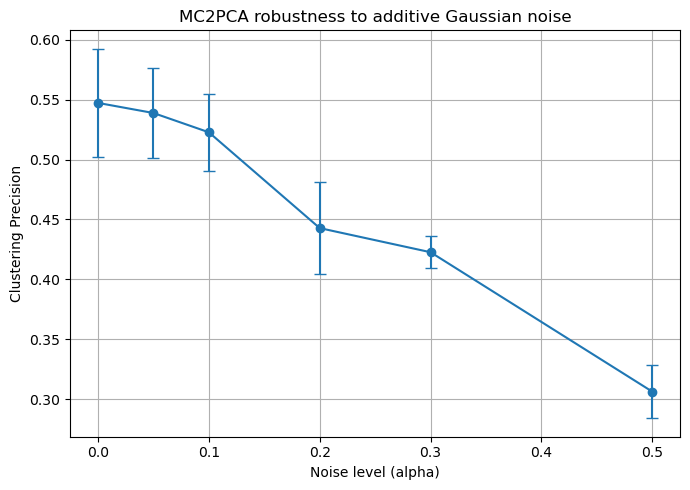

In [12]:
df = pd.DataFrame(metrics.results)
grouped = df.groupby("noise")["Precision"].agg(["mean", "std"])

plt.figure(figsize=(7,5))
plt.errorbar(
    grouped.index,
    grouped["mean"],
    yerr=grouped["std"],
    marker="o",
    capsize=4
)

plt.xlabel("Noise level (alpha)")
plt.ylabel("Clustering Precision")
plt.title("MC2PCA robustness to additive Gaussian noise")
plt.grid(True)
plt.tight_layout()
plt.show()


# Evaluate precision vs. missing data 


In [9]:
def add_missing_data(X, missing_rate, seed=None):
    rng = np.random.default_rng(seed)
    X_missing = []

    for Xi in X:
        T = Xi.shape[0]
        n_remove = int(missing_rate * T)

        if n_remove == 0:
            X_missing.append(Xi)
            continue

        keep_idx = rng.choice(T, size=T - n_remove, replace=False)
        keep_idx = np.sort(keep_idx)

        X_missing.append(Xi[keep_idx])

    return X_missing


missing_rates = [0.0, 0.05, 0.1, 0.2, 0.3, 0.5]
n_runs = 10

K = 9
p = 3

metrics = ClusteringMetrics()

for mr in missing_rates:
    for run in range(n_runs):

        perm = np.random.permutation(len(X_train))
        X_perm = [X_train[i] for i in perm]
        y_perm = y_true[perm]

        X_missing = add_missing_data(X_perm, missing_rate=mr, seed=run)

        model = MC2PCA(p=p, tol=1e-7, max_iter=50)
        model.fit(X_missing, K=K)

        metrics.add_run(
            y_true=y_perm,
            y_pred=model.assignments,
            p=p,
            noise=None,
            errors=model.errors,
        )

    subset = [
        r for r in metrics.results
        if r["p"] == p and r.get("noise") is None
    ]
    precs = [r["Precision"] for r in subset[-n_runs:]]

    print(
        f"missing={mr:.2f} | Precision = "
        f"{np.mean(precs):.3f} ± {np.std(precs):.3f}"
    )


missing=0.00 | Precision = 0.573 ± 0.027
missing=0.05 | Precision = 0.552 ± 0.027
missing=0.10 | Precision = 0.537 ± 0.041
missing=0.20 | Precision = 0.557 ± 0.027
missing=0.30 | Precision = 0.528 ± 0.035
missing=0.50 | Precision = 0.502 ± 0.032


# Evalutate precision vs missing data at the beginning of the signal 

cut_begin=0.00 | Precision = 0.550 ± 0.028
cut_begin=0.05 | Precision = 0.555 ± 0.041
cut_begin=0.10 | Precision = 0.546 ± 0.025
cut_begin=0.20 | Precision = 0.520 ± 0.029
cut_begin=0.30 | Precision = 0.517 ± 0.024
cut_begin=0.50 | Precision = 0.437 ± 0.037


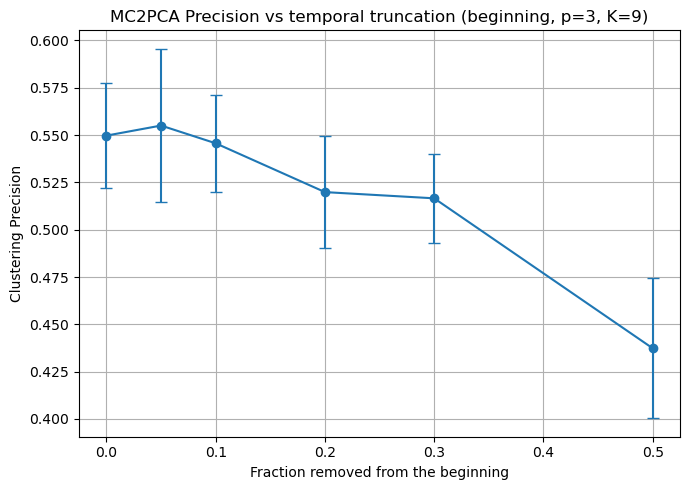

In [14]:
def cut_beginning(X, cut_rate):
    X_cut = []
    for Xi in X:
        T = Xi.shape[0]
        cut = int(cut_rate * T)
        X_cut.append(Xi[cut:])
    return X_cut


cut_rates = [0.0, 0.05, 0.1, 0.2, 0.3, 0.5]
n_runs = 10

K = 9
p = 3

mean_prec_begin = []
std_prec_begin = []

for cr in cut_rates:
    precs = []

    for run in range(n_runs):

        perm = np.random.permutation(len(X_train))
        X_perm = [X_train[i] for i in perm]
        y_perm = y_true[perm]

        X_cut = cut_beginning(X_perm, cut_rate=cr)

        model = MC2PCA(p=p, tol=1e-7, max_iter=50)
        model.fit(X_cut, K=K)

        metrics = ClusteringMetrics()
        metrics.add_run(
            y_true=y_perm,
            y_pred=model.assignments,
            p=p
        )

        precs.append(metrics.results[-1]["Precision"])

    mean_prec_begin.append(np.mean(precs))
    std_prec_begin.append(np.std(precs))

    print(
        f"cut_begin={cr:.2f} | Precision = "
        f"{np.mean(precs):.3f} ± {np.std(precs):.3f}"
    )


plt.figure(figsize=(7,5))

plt.errorbar(
    cut_rates,
    mean_prec_begin,
    yerr=std_prec_begin,
    marker="o",
    capsize=4
)

plt.xlabel("Fraction removed from the beginning")
plt.ylabel("Clustering Precision")
plt.title(f"MC2PCA Precision vs temporal truncation (beginning, p={p}, K={K})")
plt.grid(True)
plt.tight_layout()
plt.show()


# Evalutate precision vs missing data at the end of the signal 

cut_end=0.00 | Precision = 0.537 ± 0.040
cut_end=0.05 | Precision = 0.550 ± 0.026
cut_end=0.10 | Precision = 0.513 ± 0.027
cut_end=0.20 | Precision = 0.476 ± 0.032
cut_end=0.30 | Precision = 0.457 ± 0.040
cut_end=0.50 | Precision = 0.407 ± 0.044


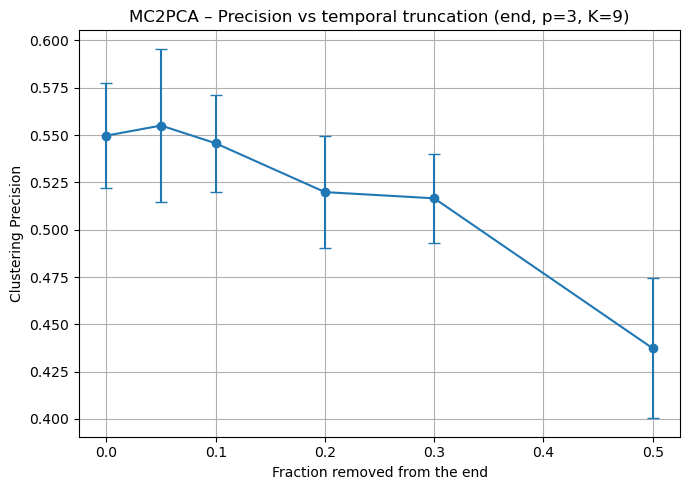

In [15]:
def cut_end(X, cut_rate):
    X_cut = []
    for Xi in X:
        T = Xi.shape[0]
        cut = int(cut_rate * T)
        X_cut.append(Xi[:-cut] if cut > 0 else Xi)
    return X_cut


mean_prec_end = []
std_prec_end = []

for cr in cut_rates:
    precs = []

    for run in range(n_runs):

        perm = np.random.permutation(len(X_train))
        X_perm = [X_train[i] for i in perm]
        y_perm = y_true[perm]

        X_cut = cut_end(X_perm, cut_rate=cr)

        model = MC2PCA(p=p, tol=1e-7, max_iter=50)
        model.fit(X_cut, K=K)

        metrics = ClusteringMetrics()
        metrics.add_run(
            y_true=y_perm,
            y_pred=model.assignments,
            p=p
        )

        precs.append(metrics.results[-1]["Precision"])

    mean_prec_end.append(np.mean(precs))
    std_prec_end.append(np.std(precs))

    print(
        f"cut_end={cr:.2f} | Precision = "
        f"{np.mean(precs):.3f} ± {np.std(precs):.3f}"
    )


plt.figure(figsize=(7,5))

plt.errorbar(
    cut_rates,
    mean_prec_begin,
    yerr=std_prec_begin,
    marker="o",
    capsize=4
)

plt.xlabel("Fraction removed from the end")
plt.ylabel("Clustering Precision")
plt.title(f"MC2PCA – Precision vs temporal truncation (end, p={p}, K={K})")
plt.grid(True)
plt.tight_layout()
plt.show()